In [4]:
from pyspark.sql import SparkSession
import pandas as pd

spark = SparkSession.builder.appName("DataSetup").getOrCreate()

customers_data = [
    ("C01", "Nguyen Van A", "Ha Noi", "VIP"),
    ("C02", "Tran Thi B", "Ho Chi Minh", "Standard"),
    ("C03", "Le Van C", "Da Nang", "VIP"),
    ("C04", "Pham Thi D", "Ha Noi", "Standard"),
    ("C05", "Hoang Van E", "Hai Phong", "New")
]
df_customers = spark.createDataFrame(customers_data, ["customer_id", "customer_name", "city", "segment"])

jdbc_url = "jdbc:postgresql://postgres:5432/retail_db"
properties = {"user": "admin", "password": "admin", "driver": "org.postgresql.Driver"}
df_customers.write.jdbc(url=jdbc_url, table="customers", mode="overwrite", properties=properties)

orders_data = [
    ("O001", "C01", "2026-05-01", "1500000"),
    ("O002", "C02", "2026-05-02", "500000"),
    ("O003", "C01", "2026-05-03", "2000000"),
    ("O004", "C03", "2026-05-03", "-100000"),
    ("O005", None,  "2026-05-04", "300000"),  
    ("O006", "C04", "2026-05-05", "1200000"),
    ("O007", "C05", "2026-05-05", "0"),       
    ("O008", "C03", "2026-05-06", "4500000"),
    ("O009", "C02", "2026-05-06", None)       
]
df_orders = pd.DataFrame(orders_data, columns=["order_id", "customer_id", "order_date", "amount"])
df_orders.to_csv("orders.csv", index=False)


[8.1] Tổng doanh thu theo City:
+-----------+-------------+
|       city|total_revenue|
+-----------+-------------+
|    Da Nang|    4500000.0|
|     Ha Noi|    4700000.0|
|Ho Chi Minh|     500000.0|
+-----------+-------------+


[8.2] Tổng doanh thu theo Segment:
+--------+-------------+
| segment|total_revenue|
+--------+-------------+
|     VIP|    8000000.0|
|Standard|    1700000.0|
+--------+-------------+


[8.3] Top 10 khách hàng chi tiêu cao nhất:
+-----------+-------------+--------------+
|customer_id|customer_name|total_spending|
+-----------+-------------+--------------+
|        C03|     Le Van C|     4500000.0|
|        C01| Nguyen Van A|     3500000.0|
|        C04|   Pham Thi D|     1200000.0|
|        C02|   Tran Thi B|      500000.0|
+-----------+-------------+--------------+


[*] Đang ghi dữ liệu chuẩn ra Parquet...
✅ Đã ghi thành công file Parquet tại: s3a://logs/final_analysis.parquet


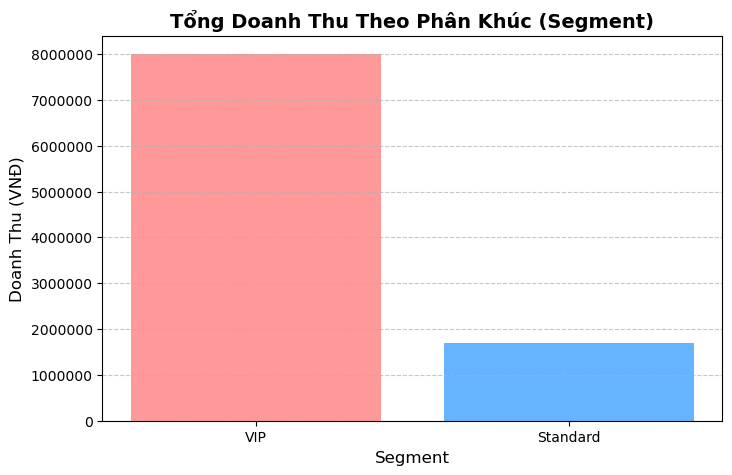

In [5]:
from pyspark.sql.functions import col, desc, sum
import matplotlib.pyplot as plt

hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()
hadoop_conf.set("fs.s3a.endpoint", "http://minio:9000")
hadoop_conf.set("fs.s3a.access.key", "admin")
hadoop_conf.set("fs.s3a.secret.key", "password123")
hadoop_conf.set("fs.s3a.path.style.access", "true")
hadoop_conf.set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
hadoop_conf.set("fs.s3a.connection.ssl.enabled", "false")
hadoop_conf.set("fs.s3a.threads.keepalivetime", "60")
hadoop_conf.set("fs.s3a.connection.establish.timeout", "5000")
hadoop_conf.set("fs.s3a.connection.timeout", "200000")
hadoop_conf.set("fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider")
hadoop_conf.set("fs.s3a.multipart.purge.age", "86400")

df_customers = spark.read.jdbc(url=jdbc_url, table="customers", properties=properties)
df_orders_raw = spark.read.csv("s3a://logs/orders.csv", header=True, inferSchema=False)

df_orders_clean = df_orders_raw \
    .dropna(subset=["customer_id", "amount"]) \
    .withColumn("amount", col("amount").cast("double")) \
    .filter(col("amount") > 0)

df_joined = df_orders_clean.join(df_customers, on="customer_id", how="inner")
print("\n[8.1] Tổng doanh thu theo City:")
df_city_rev = df_joined.groupBy("city").agg(sum("amount").alias("total_revenue"))
df_city_rev.show()

print("\n[8.2] Tổng doanh thu theo Segment:")
df_segment_rev = df_joined.groupBy("segment").agg(sum("amount").alias("total_revenue"))
df_segment_rev.show()

print("\n[8.3] Top 10 khách hàng chi tiêu cao nhất:")
df_joined.groupBy("customer_id", "customer_name") \
    .agg(sum("amount").alias("total_spending")) \
    .orderBy(desc("total_spending")) \
    .limit(10) \
    .show()

print("\n[*] Đang ghi dữ liệu chuẩn ra Parquet...")
output_path = "s3a://logs/final_analysis.parquet"
df_joined.write.mode("overwrite").parquet(output_path)
print(f"✅ Đã ghi thành công file Parquet tại: {output_path}")

pdf_segment = df_segment_rev.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(pdf_segment['segment'], pdf_segment['total_revenue'], color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Tổng Doanh Thu Theo Phân Khúc (Segment)", fontsize=14, fontweight='bold')
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Doanh Thu (VNĐ)", fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Tắt định dạng số khoa học (1e6) ở trục Y
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()